# Marketplace Safety - Prioritering av misstänkta annonser och meddelanden

**Bakgrund**  
Detta projekt är utfört på uppdrag av analysteamet på ett företag som driver en marknadsplats-app, liknande Blocket. Plattformen används dagligen av ett stort antal användare där de allra flesta är seriösa. Varje vecka förekommer dock en mindre andel problematiska aktiviteter: bluffannonser, spam, misstänkta konton som agerar snabbt samt försök att flytta konversationer utanför plattformen.

**Problem**  
Företagets Trust & Safety-team granskar och hanterar misstänkt innehåll manuellt. Problemet är att volymen är för stor för att teamet ska hinna granska allt i tid. Ledningen efterfrågar därför ett beslutsstöd som hjälper teamet att prioritera vad som ska granskas först.

**Mål**  
Målet är att leverera en lösning som:
- presterar rimligt bra på ny, osedd data
- går att köra regelbundet i produktion
- kan förklaras för icke-tekniska stakeholders

Fokus ligger på prioritering och beslutstöd.

**Stakeholder**   
Att fylla i på slutet av projektet (kravkortet är en hemlis  🤫)

Kolumnnamn | Förklaring |
|---|---|
| `id` | Unikt identifieringsnummer för varje post |
| `day` | Dagen då händelsen inträffade |
| `event_type` | Typ av händelse (t.ex. visning, meddelande, anmälan) |
| `category` | Produktkategori för annonsen |
| `region` | Geografiskt område där annonsen publicerades |
| `device` | Enhetstyp som användes (t.ex. mobil, dator) |
| `account_age_days` | Antal dagar sedan kontot skapades |
| `num_prev_listings` | Antal tidigare annonser från samma användare |
| `prev_reports_30d` | Antal gånger användaren anmälts de senaste 30 dagarna |
| `verification_level` | Verifieringsnivå för kontot |
| `price` | Annonsens pris |
| `num_images` | Antal bilder i annonsen |
| `message_length` | Längden på meddelandet i annonsen |
| `contains_off_platform` | Om användaren försökt flytta konversationen utanför plattformen |
| `urgency_words` | Om annonsen innehåller ord som skapar artificiell brådska |
| `payment_attempt` | Om ett betalningsförsök har skett |
| `time_to_first_response_min` | Tid i minuter till första svar |
| `is_suspicious` | Målvariabel — om annonsen är misstänkt (1) eller inte (0) |

In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from copy import deepcopy

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

# 1) Data & EDA (Isabel)

- Visa datasetstorlek, datatyper och target-fördelning.
- Kontrollera saknade värden och beskriv hur ni hanterar dem.
- Minst 2 figurer/tabeller + kort tolkning.

In [37]:
df = pd.read_csv("../data/historical_data.csv")
df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [38]:
print("Datasets storlek:", df.shape)
print("---------------------------")

Datasets storlek: (12000, 18)
---------------------------


In [39]:
print("Datatyper")
print("---------------------------")
df.info()

Datatyper
---------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  cont

### Summering av dataset

- Datasetet innehåller 12,000 observationer och 18 variabler
- Text variabler är av typ *string* och numeriska variabler är av typerna *int64* och *float64*
- Det finns fyra kategoriska värden: *event_type*, *category*, *region*, *device*
- Target är *is_suspicious*: 0 = ej misstänkt, 1 = misstänkt

## Missing values

In [40]:
print("-------------------------------")
print("Saknade värden per kolumn (antal):")
print("-------------------------------")
print(df.isna().sum())
print("-------------------------------")
print("Saknade värden per kolumn (%):")
print("-------------------------------")
df.isnull().sum() / len(df) * 100

-------------------------------
Saknade värden per kolumn (antal):
-------------------------------
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64
-------------------------------
Saknade värden per kolumn (%):
-------------------------------


id                            0.000000
day                           0.000000
event_type                    0.000000
category                      0.000000
region                        2.833333
device                        0.000000
account_age_days              0.000000
num_prev_listings             0.000000
prev_reports_30d              0.000000
verification_level            0.000000
price                         6.816667
num_images                    0.000000
message_length                0.000000
contains_off_platform         0.000000
urgency_words                 0.000000
payment_attempt               0.000000
time_to_first_response_min    4.916667
is_suspicious                 0.000000
dtype: float64

### Hantering av saknade värden

Andelen saknade värden är relativt låg:
- *region*: 340 (2.83 %)
- *price*: 818 (6.81 %)
- *time_to_first_response_min*: 590 (4.91%)

Eftersom klassen är obalanserad är det mindre lämpligt att droppa rader, då procent av saknade värden inte är tillräckligt låg, i ett redan obalancerat problem kan minoiritetsklassen påverkas oproportioneligt. I detta fall är det istället bättre att imputera värdena.

Saknade värden kommer därför att imputeras i pipeline med hjälp av `SimpleImputer` för att minska data-läckage genom att imputering beräknas bara på träningsdatan och sedan att samma transformation appliceras på testdata. Det gör processen reproducerbar och säker i cross-validation. 

**Numeriska variabler:**
- Saknade värden kommer att ersättas med medianen (som är tålig mot outliers) för respektive numerisk kolumn. 
- `add_indicator=True` kommer att användas för att lägga till en extra binär kolumn för varje variabel som haft saknade värden: *0 = värdet fanns, 1 = värdet saknades*. För att modellen ska kunna lära sig om ett saknat värde tenderar att tillhöra en viss klass. 
- Efter imputering standardiseras variablerna med `StandardScaler`.

**Kategoriska variabler:**
- Sakande kategoriska värden kommer att ersättas med "unknown". 
- Därefter kommer `OneHotEncoder`att användas för att göra "unknown" till sin egen kategori, för att undvika felaktig information genom att fylla med en befintlig kategori. 
- `handle_unknow="ignore"` hjälper till med att hantera att nya kategorier i testdata inte orsakar fel.

## Definera X och y

In [41]:
X_full = df.drop(["is_suspicious"], axis=1)
y_full = df["is_suspicious"]

print("X:", X_full.shape, "y:", y_full.shape)

X: (12000, 17) y: (12000,)


## Klassfördelning av target (misstänkt aktivitet)

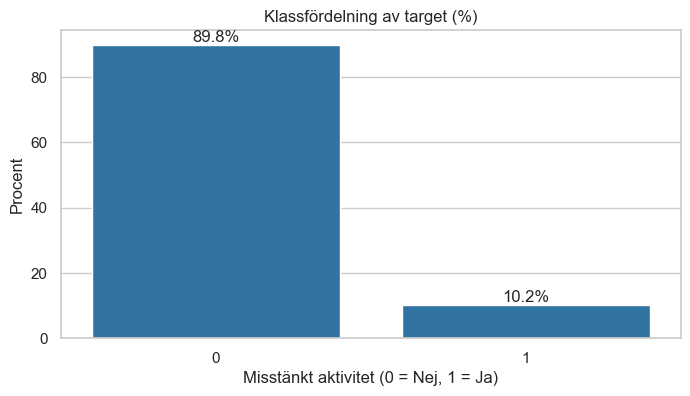

In [42]:
class_dist = y_full.value_counts(normalize=True) * 100

ax = sns.barplot(
    x=class_dist.index,
    y=class_dist.values
)

plt.ylabel("Procent")
plt.xlabel("Misstänkt aktivitet (0 = Nej, 1 = Ja)")
plt.title("Klassfördelning av target (%)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### Summering av klassfördelning
Klassfördelningen visar en tydlig obalans i datan: endast 10 % av de historiska observationerna är klassade som misstänkt aktivitet. Detta är dock förväntat, eftersom andelen misstänkt aktivitet normalt sett är låg.

## Korrelationer med target (misstänkt aktivitet)

Korrelationer visar hur starkt numeriska features separerar misstänkt aktivitet från icke-misstänkt. Kategoriska variabler utesluts eftersom korrelation mäter det linjära sambandet mellan två numeriska variabler.

In [43]:
corr_with_target = X_full.copy()
corr_with_target["is_suspicious"] = y_full

corr_with_target = (
    corr_with_target
    .drop(["event_type", "category", "region", "device"], axis=1)
    .corr()["is_suspicious"]
    .sort_values(ascending=False)
)

print(corr_with_target)

is_suspicious                 1.000000
contains_off_platform         0.141828
prev_reports_30d              0.130920
urgency_words                 0.087295
payment_attempt               0.066666
price                         0.011883
num_images                    0.009446
id                            0.005236
day                          -0.007565
message_length               -0.011989
time_to_first_response_min   -0.013942
num_prev_listings            -0.015895
verification_level           -0.100409
account_age_days             -0.103146
Name: is_suspicious, dtype: float64


### Summering korrelerande features

De två features som visar högst positiv korrelation med misstänkt aktivitet är *contains_off_platform* (0,14) och *prev_reports_30d* (0,13). Även om dessa samband är relativt svaga kan de ändå vara värdefulla i obalanserade klassificeringsproblem, eftersom effekten sannolikt är icke-linjär. Det finns troligen en tröskeleffekt, och dessa features kan ha större betydelse i kombination med andra variabler.

## Andel misstänka aktiviteter per kategori

Andelen misstänkt aktivitet analyseras för respektive kategorisk variabel för att undersöka om någon kategori sticker ut med en högre förekomst av misstänkt aktivitet.

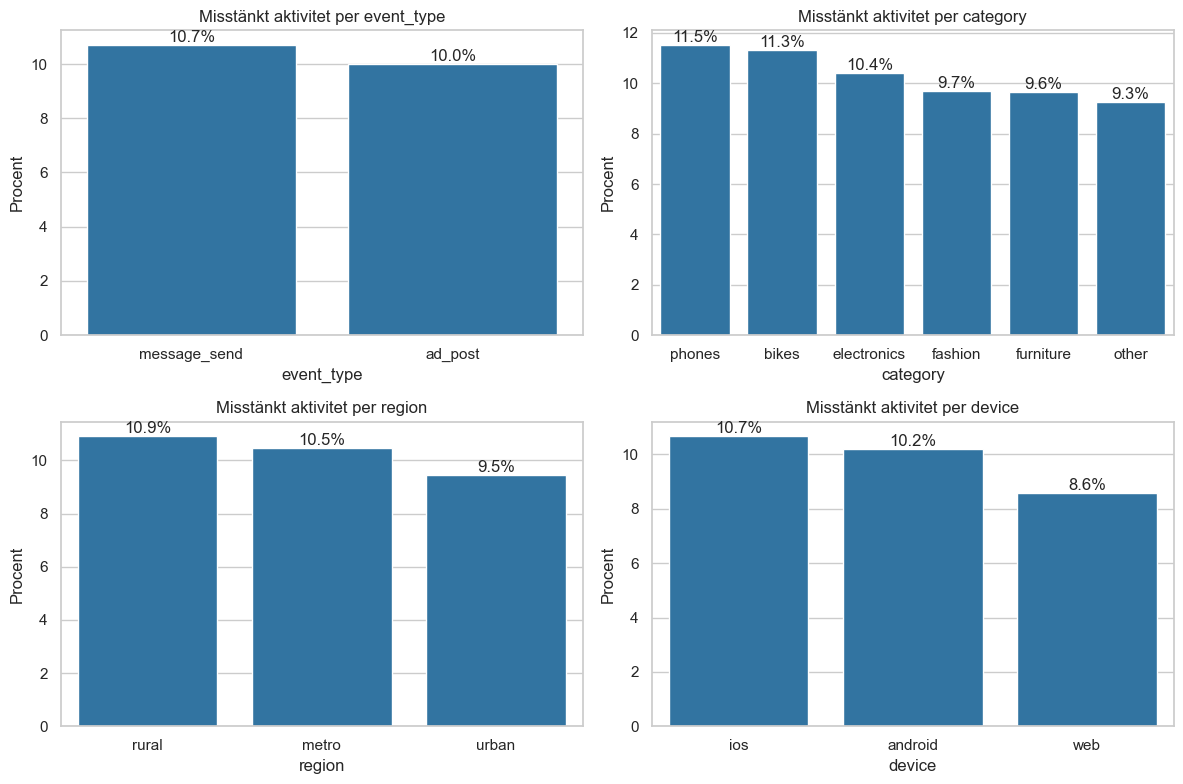

In [44]:
categorical_cols = [
    "event_type",
    "category",
    "region",
    "device"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  
axes = axes.flatten() 

temp_df = pd.concat([X_full, y_full.rename("is_suspicious")], axis=1)

for i, col in enumerate(categorical_cols):
    susp_count = (
        temp_df
        .groupby(col)["is_suspicious"]
        .mean()
        .sort_values(ascending=False) * 100
    )
    
    ax = sns.barplot(
        x=susp_count.index,
        y=susp_count.values,
        ax=axes[i]
    )
    
    ax.set_ylabel("Procent")
    ax.set_title(f"Misstänkt aktivitet per {col}")
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Summering av misstänkt aktivitet per kategori
Analysen av historisk data visar inga tydliga skillnader mellan kategorier när det gäller andelen misstänkt aktivitet. Fördelningen av misstänkta händelser inom de olika kategorierna speglar i stort den övergripande klassfördelningen och ligger konsekvent runt 10 %.

# 2) Pipeline & preprocessing (Irene)

- Skapa en train/test-split från historical_data.csv.
- Bygg en pipeline där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).
- För klassificering: använd gärna stratified split så klasserna fördelas rimligt.

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,12000.0,5999.500000,3464.245950,0.00,2999.750,5999.500,8999.250,11999.00
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("-------------------------------")
print(f"Classification train: \n{y_train.value_counts(normalize=True)}")
print("-------------------------------")
print(f"Classification test: \n{y_test.value_counts(normalize=True)}")
print("-------------------------------")

Train: (9600, 17) (9600,)
Test: (2400, 17) (2400,)
-------------------------------
Classification train: 
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64
-------------------------------
Classification test: 
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64
-------------------------------


### Summering av train/test split

Vi delar upp datan i tränings- och testset med en 80/20-fördelning. **stratify=y_full** garanterar att andelen misstänkta och icke-misstänkta fall är proportionerligt lika i både tränings- och testset.

In [47]:
def engineer_features(X):
    X = X.copy()
    X["report_rate"] = X["prev_reports_30d"] / (X["num_prev_listings"] + 1)
    X["risk_score"] = X["contains_off_platform"] + X["urgency_words"] + X["payment_attempt"]
    return X

feature_engineer = FunctionTransformer(engineer_features)

### Summering av feature engineering

Vi skapar två nya features baserade på befintliga kolumner:
- **report_rate** normaliserar antalet anmälningar mot användarens aktivitetsnivå
- **risk_score** summerar tre binära varningssignaler till ett enda riskindex

Feature engineering handlar om att skapa nya variabler från den data vi redan har, med målet att göra mönstren tydligare för modellen.  

Dessa transformationer är inlindade i en FunctionTransformer så att de körs inuti pipelinen och aldrig appliceras före train/test-spliten.

In [48]:
numeric_features = ["account_age_days", "num_prev_listings", "prev_reports_30d",
    "price", "num_images", "message_length", "verification_level",
    "time_to_first_response_min", "payment_attempt",
    "contains_off_platform", "urgency_words",
    # engineered features:
    "report_rate", "risk_score"]

categorical_features = ["event_type", "category", "region", "device"]

### Summering av feature selection

De numeriska och kategoriska variablerna separerades eftersom de kräver olika typer av förbehandling:  
- Numeriska variabler behöver skalas med StandardScaler för att en model som Logistic Regression inte ska påverkas av att olika kolumner har olika storleksordning.  
- Kategoriska variabler behöver istället omvandlas till binära kolumner med OneHotEncoder.

Kolumnerna **id** och **day** exkluderades eftersom den första är ett unikt identifieringsnummer utan prediktivt värde, medans den andra är ett gränsfallsbeslut som kan leda till att modellen lär sig slumpen istället för verkliga beteendemönster.

In [49]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

### Summering av transformers

Vi definierar två separata transformers:
- Den numeriska transformern hanterar saknade värden med medianvärdet och använder add_indicator=True för att skapa en binär kolumn som markerar var värden saknades. Detta ger modellen möjlighet att lära sig om det finns ett samband mellan saknade värden och misstänkt aktivitet. 
- Därefter standardiseras värdena med StandardScaler. Den kategoriska transformern fyller saknade värden med konstanten "Unknown" så att missingness bevaras som en egen kategori, följt av OneHotEncoder som omvandlar textvärden till binära kolumner som modellen kan tolka.

Anledningen är att ett saknat värde i dessa kolumner potentiellt är informativt i sig: en säljare som döljer priset eller aldrig svarar kan vara ett tecken på misstänkt aktivitet.

In [50]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Vi kombinerar de två transformers i en ColumnTransformer som applicerar rätt transformer på rätt kolumner.

**remainder="drop"** säkerställer att kolumner som inte finns i någon av listorna ignoreras.

In [51]:
full_pipeline = Pipeline(steps=[
    ("features", feature_engineer),
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eng...00193CCC15800>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to

### Summering av pipeline

Vi sätter ihop alla steg i en sammanhängande Pipeline:   
- feature engineering  
- preprocessing  
- modell  

Fördelen med en pipeline är att alla transformationer appliceras automatiskt och konsekvent på både tränings- och testdata, vilket eliminerar risken för data leakage.  

För att byta model kan vi bara byta ut LogisticRegression mot en annan och allt annat fungerar automatiskt.

# 3) Modelljämförelse (Nora)

- Skapa en baseline.
- Träna minst två ytterligare modeller (minst 3 totalt inkl baseline).
- Utvärdera med rimlig metod (t.ex. cross-validation på train eller tydligt valideringsupplägg)
- Välj metric och motivera valet utifrån ert kravkort.
- (Exempel på modeller: LogisticRegression, DecisionTree, RandomForest, GradientBoosting…)

I detta avsnitt jämför vi flera klassificeringsmodeller för att identifiera misstänkta aktiviteter på plattformen. Vi utgår från vårt kravkort (COO/Finance), vilket innebär att vårt fokus ligger på att visa risk–vs–arbetsbelastning, inte bara vilken modell som ger högst score.

(baseline + minst 2 modeller + CV)

Vi vill ha:
- tydliga tradeoffs (tid för granskning vs risk att missa)
- minst 2–3 alternativ
- en beslutsbar kompromiss inte tekniska detaljer, utan konsekvenser

Det betyder att du måste välja metric som visar balans, t.ex.:
- Recall
- Precision
- F1
- Kostnadstabell (FP/FN)
- Alternativt: confusion matrix per modell

### Baseline-modell
Som referens använder vi en baseline-modell (`DummyClassifier`) som alltid förutsäger majoritetsklassen. Baseline används för att visa (hur dåligt resultatet blir om företaget inte gör något alls).

Detta ger COO en tydlig bild av vad vår modell behöver slå för att motivera investering i beslutsstödet.

In [52]:
baseline_clf = deepcopy(full_pipeline).set_params(classifier=DummyClassifier(strategy="most_frequent"))

scores_baseline = cross_val_score(baseline_clf, X_train, y_train, cv=5, scoring="f1")
scores_baseline.mean()

np.float64(0.0)

### Modeller som jämförs
Vi jämför tre modeller:

1. Baseline (DummyClassifier) – referenspunkt.
2. Logistic Regression – enkel, tolkningsbar och lätt att förklara.
3. Random Forest – robust modell som fångar icke-linjära samband.

Valet av modeller motiveras av vårt kravkort:
- Logistic Regression ger tydlighet och förklarbarhet.
- Random Forest ger stabilitet och högre upptäcktsförmåga.
- Kombinationen ger en meningsfull jämförelse mellan tolkbarhet och prestanda.


In [53]:
# Logistic Regression
logreg_clf = deepcopy(full_pipeline).set_params(classifier=LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))

# Random Forest (standardvärden går bra — tuning kommer i uppgift 4)
rf_clf = deepcopy(full_pipeline).set_params(classifier=RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", max_depth=10))


### Cross-validation (CV)
För att utvärdera modellerna använder vi 5-fold cross-validation på `X_train`.  
Scoring-metric: **F1-score**.

Motivering till val av metric:
- Datat är obalanserat.
- F1 balanserar precision och recall.
- COO vill förstå avvägningen mellan “granskningstid” (FP) och “missade bedrägerier” (FN).


In [54]:
# Cross-validation
scores_logreg  = cross_val_score(logreg_clf,  X_train, y_train, cv=5, scoring="f1")
scores_rf      = cross_val_score(rf_clf,      X_train, y_train, cv=5, scoring="f1")

print("Baseline F1:", scores_baseline.mean())
print("Logistic Regression F1:", scores_logreg.mean())
print("Random Forest F1:", scores_rf.mean())


Baseline F1: 0.0
Logistic Regression F1: 0.3026495130161349
Random Forest F1: 0.27014822252549886


### Summering av modell jämförelse

I grundjämförelsen presterade Logistic Regression bäst (F1 ≈ 0.302), medan Random Forest hade något lägre grundprestanda (F1 ≈ 0.27). 
Vi väljer ändå att gå vidare med att optimera Random Forest. Skälet är att Random Forest har större förbättringspotential genom hyperparameter‑tuning och att modellen ger sannolikheter som fungerar bättre för våra threshold‑scenarier. 
Det gör det möjligt att styra balansen mellan risk (FN) och arbetsbelastning (FP) enligt kravkortet.

# 4) Optimering (Ummulbanin)

- Välj en “final” modell baserat på jämförelsen.
- Gör tuning på den valda modellen (litet grid, minst 1–2 parametrar).
- Förklara kort vad ni optimerade och varför (koppla till kravkortet).

### Hyperparameter tuning (GridSearch)

Parametrarna påverkar modellens komplexitet och generaliseringsförmåga. GridSearchCV användes för att optimera:

| Parameter | vad den gör | 
|---------|-----------|
| **n_estimators** | Antal träd i Random Forest. Fler träd kan ge stabilare och mer robusta prediktioner, men ökar också beräkningstiden. | 
| **max_depth** | Bestämmer hur djupt varje träd får växa. Ett lägre värde begränsar trädets komplexitet och kan minska överanpassning, medan ett högre värde gör att modellen kan fånga mer komplexa mönster i datan.| 
| **min_samples_leaf** | Minsta antal observationer som måste finnas i ett blad. Ett högre värde gör modellen mer generell och kan minska överanpassning, medan ett lägre värde gör modellen mer flexibel.| 


Tuning av dessa parametrar görs med GridSearchCV för att maximera F1-score, beroende på vilken trade-off man vill prioritera.

In [55]:
rf_clf = deepcopy(full_pipeline).set_params(
    classifier=RandomForestClassifier(random_state=42, class_weight= "balanced")
)

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [ 10, 20],
    "classifier__min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(
    rf_clf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300}
Best CV F1: 0.320775358780087


In [56]:
best_model = grid_search.best_estimator_

In [57]:
y_pred = best_model.predict(X_test)
print("Detaljer per klass (classification_report)")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("---------------------------------")
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")

print("---------------------------------")
print("Tolkning:")
print("- FP: vi flaggade misstänkt, men det var egentligen normal aktivitet")
print("- FN: vi missade misstänkt aktivitet")

results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "cm": cm
}

print(results)

Detaljer per klass (classification_report)
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      2155
           1       0.29      0.47      0.36       245

    accuracy                           0.83      2400
   macro avg       0.61      0.67      0.63      2400
weighted avg       0.87      0.83      0.85      2400

---------------------------------
TN=1875, FP=280, FN=129, TP=116
---------------------------------
Tolkning:
- FP: vi flaggade misstänkt, men det var egentligen normal aktivitet
- FN: vi missade misstänkt aktivitet
{'accuracy': 0.8295833333333333, 'precision': 0.29292929292929293, 'recall': 0.47346938775510206, 'f1': 0.3619344773790952, 'cm': array([[1875,  280],
       [ 129,  116]])}


### Summering av resultat
Resultaten visar att modellen flaggar relativt många observationer som misstänkt aktivitet. Av de flaggade fallen är en del verkliga bedrägerier (TP = 116), men modellen genererar också många falska larm (FP = 280).

Modellen lyckas identifiera cirka 47 % av de faktiska bedrägerierna (recall), men 129 fall missas fortfarande (FN).

Detta illustrerar den tydliga trade-offen mellan granskningstid och risk för missade bedrägerier: modellen hittar fler bedrägerier, men på bekostnad av fler falska larm.

# 5) Threshold/prioritering (Abdullahi)

Efter modelloptimeringen behöver vi bestämma hur modellen ska användas i praktiken. 
Vi har valt ut alternativ A och därför kommer vi att analyserar olika threshold-nivåer för att visa hur valet påverkar 
arbetsbelastning (FP) och affärsrisk (FN).

Threshold-beslut:
- flagga misstänkt om proba ≥ t
- motivera t utifrån kravkortet och visa konsekvenser (FP/FN eller precision/recall)

In [58]:
y_proba = best_model.predict_proba(X_train)[:, 1]

thresholds = [0.20, 0.35, 0.50,0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
results = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)

    cm = confusion_matrix(y_train, preds)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Threshold": t,
        "FP": fp,
        "FN": fn,
        "Precision": precision_score(y_train, preds),
        "Recall": recall_score(y_train, preds),
        "F1": f1_score(y_train, preds),
        "Flagged cases": preds.sum()
    })

df_results = pd.DataFrame(results)
df_results

,Threshold,FP,FN,Precision,Recall,F1,Flagged cases
0,0.20,6245,1,0.135401,0.998979,0.238478,7223
1,0.35,3050,42,0.235014,0.957099,0.377366,3987
2,0.50,873,197,0.472508,0.798774,0.593774,1655
3,0.55,487,316,0.576522,0.677222,0.622828,1150
4,0.60,213,460,0.709016,0.530133,0.606663,732
5,0.65,81,594,0.826180,0.393258,0.532872,466
6,0.70,22,729,0.919118,0.255363,0.399680,272
7,0.75,4,842,0.971631,0.139939,0.244643,141
8,0.80,0,924,1.000000,0.056180,0.106383,55


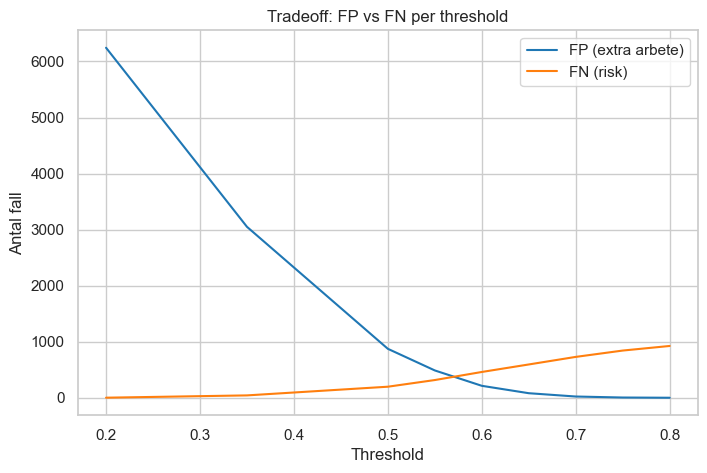

In [59]:
# Ha kvar? Isf fixa så grafen funkar 

plt.figure(figsize=(8,5))
plt.plot(df_results["Threshold"], df_results["FP"], label="FP (extra arbete)")
plt.plot(df_results["Threshold"], df_results["FN"], label="FN (risk)")
plt.xlabel("Threshold")
plt.ylabel("Antal fall")
plt.title("Tradeoff: FP vs FN per threshold")
plt.legend()
plt.grid(True)
plt.show()

### Tolkning av resultat

För att visa tradeoffen mellan granskningskostnad och affärsrisk analyserade vi tre tydliga scenarier:

Vi analyserade flera threshold-nivåer för att förstå tradeoffen mellan arbetsbelastning (FP) och affärsrisk (FN).

| Scenario | Threshold | Flagged cases | Missade fall (FN) | Affärslogik |
|----------|-----------|--------------|-------------------|-------------|
| A: Riskminimering | 0.20 | 7223 | 1 | Nästan ingen risk, men extrem arbetsbelastning |
| B: Balanserad kompromiss (rekommenderad) | 0.35 | 3987 | 42 | Kontrollerad risk och rimlig granskningskostnad |
| C: Kostnadsminimering | 0.50 | 1655 | 197 | Lägre kostnad men kraftigt ökad affärsrisk |

Detta visar en tydlig tradeoff:
- Låg threshold ger låg risk men hög kostnad
- Hög threshold ger låg kostnad men hög risk
- 0.35 ligger mitt emellan och ger en balanserad kompromiss

Vi valde tidigare F1 som metric för att hitta en rimlig balans i recall och precision då båda är viktigt för att hitta så mycket misstänkt aktivitet som möjligt. Utifrån det väljer vi även att göra en rimlighetsbedömning gällande threshold också och föreslår därför **Scenario B** som en rimlig kompromiss mellan kostnad och risk. 

## Final test

Slutligen gör vi ett sluttest av threshold på testdatan för att se hur väl den valda thresholden presterar på modellen med den orörda testdatan. 

In [60]:
y_proba = best_model.predict_proba(X_test)[:, 1]

chosen_threshold = 0.35
results = []

preds = (y_proba >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

results.append({
    "Threshold": chosen_threshold,
    "FP": fp,
    "FN": fn,
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "Flagged cases": preds.sum()
    })

df_results = pd.DataFrame(results)
df_results


,Threshold,FP,FN,Precision,Recall,F1,Flagged cases
0,0.35,822,63,0.181275,0.742857,0.291433,1004


# 6) Deploy-test: ny data (tisdag kursvecka 6)

- När ni får new_data.csv ska ni:
- använda er låsta pipeline
- skapa prediktioner och en prioriteringslista